# Bias Correction Regression

A supervised learning notebook for predicting next-day maximum temperature using weather-station data, feature selection, model tuning, learning curves, and regression evaluation metrics.


### Cell 1  
In this step we load the original dataset, inspect its structure (shape, columns, dtypes), and check basic data quality: missing values, duplicate rows, and potential numeric outliers. This gives an overview of the raw data before any cleaning.


In [1]:
# =========================================
# Cell 1 – Imports, Load Data, Basic Info
# =========================================

import numpy as np
import pandas as pd

from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =========================
# Update this path as needed
# =========================
file_path = r"data/Bias_correction_ucl.csv"
df = pd.read_csv(file_path)

print("Original dataset shape (rows, columns):", df.shape)
display(df.head())

print("\nColumn names:\n", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nGeneral info:")
df.info()

# According to the description, these are the targets (regression outputs)
target_cols = ["Next_Tmax", "Next_Tmin"]

# Everything else is a feature
feature_cols = [col for col in df.columns if col not in target_cols]

print("\nNumber of features:", len(feature_cols))
print("Number of targets :", len(target_cols))

print("\nFeature columns:")
print(feature_cols)

print("\nTarget columns:")
print(target_cols)

# Quick check: numeric vs non-numeric features
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = [col for col in feature_cols if col not in numeric_features]

print("\nNumeric feature columns:")
print(numeric_features)

print("\nNon-numeric feature columns (e.g. Date):")
print(non_numeric_features)

# Missing values summary
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_%": missing_percent.round(2)
}).sort_values("Missing_%", ascending=False)

print("\nMissing values per column (raw):")
display(missing_summary)

# Duplicate rows
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows in raw data: {num_duplicates}")

# Outlier information (on raw data) using IQR rule
numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = []

for col in numeric_cols_raw:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_info.append({
        "Column": col,
        "Outlier_Count": outliers,
        "Outlier_%": round(outliers / len(df) * 100, 2)
    })

outliers_df_raw = pd.DataFrame(outlier_info).sort_values("Outlier_%", ascending=False)

print("\nPotential outliers per numeric column (raw, IQR rule):")
display(outliers_df_raw)


Original dataset shape (rows, columns): (7752, 25)


,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,2013-06-30,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,2013-06-30,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,2013-06-30,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,2013-06-30,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,2013-06-30,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5



Column names:
 ['station', 'Date', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope', 'Solar radiation', 'Next_Tmax', 'Next_Tmin']

Data types:
station             float64
Date                 object
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float6

,Missing_Count,Missing_%
LDAPS_RHmin,75,0.97
LDAPS_WS,75,0.97
LDAPS_Tmin_lapse,75,0.97
LDAPS_Tmax_lapse,75,0.97
LDAPS_RHmax,75,0.97
LDAPS_CC3,75,0.97
LDAPS_CC2,75,0.97
LDAPS_CC1,75,0.97
LDAPS_LH,75,0.97
LDAPS_PPT4,75,0.97



Number of duplicate rows in raw data: 0

Potential outliers per numeric column (raw, IQR rule):


,Column,Outlier_Count,Outlier_%
16,LDAPS_PPT4,1914,24.69
14,LDAPS_PPT2,1716,22.14
15,LDAPS_PPT3,1700,21.93
13,LDAPS_PPT1,1676,21.62
19,DEM,1241,16.01
20,Slope,621,8.01
7,LDAPS_WS,371,4.79
6,LDAPS_Tmin_lapse,142,1.83
4,LDAPS_RHmax,136,1.75
23,Next_Tmin,76,0.98


### Cell 2  
Here we perform strong data cleaning: convert the Date column to datetime, remove duplicate rows, drop rows with missing target values or Date, impute remaining numeric feature NaNs with the median, and clip numeric outliers using IQR-based bounds. We then confirm that missing values are handled.


In [2]:
# =========================================
# Cell 2 – Deep Cleaning: Missing, Duplicates, Outliers
# =========================================

df_clean = df.copy()

# 1) Convert Date to datetime (this will create NaT if invalid)
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%Y-%m-%d", errors="coerce")

print("Date column type after conversion:", df_clean["Date"].dtype)

# 2) Drop duplicate rows
before_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_rows = len(df_clean)
print(f"\nDuplicate rows removed: {before_rows - after_rows}")

# 3) Drop rows with missing targets or missing Date
before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=["Next_Tmax", "Next_Tmin", "Date"])
after_rows = len(df_clean)
print(f"Rows dropped due to NaN in Next_Tmax/Next_Tmin/Date: {before_rows - after_rows}")

# 4) Impute missing values in numeric feature columns (median)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
feature_num_cols = [c for c in numeric_cols if c not in ["Next_Tmax", "Next_Tmin"]]

missing_before = df_clean[feature_num_cols].isna().sum().sum()
print(f"\nTotal missing values in numeric feature columns BEFORE imputation: {missing_before}")

for col in feature_num_cols:
    if df_clean[col].isna().any():
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

missing_after = df_clean[feature_num_cols].isna().sum().sum()
print(f"Total missing values in numeric feature columns AFTER imputation: {missing_after}")

# 5) Outlier handling: clip numeric columns using IQR bounds
outlier_bounds = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = (lower, upper)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("\nOutlier handling: numeric columns clipped to IQR-based bounds.")

print("\nShape of dataset AFTER cleaning:", df_clean.shape)

# Re-check missing values summary after full cleaning
missing_counts_clean = df_clean.isna().sum()
missing_percent_clean = (missing_counts_clean / len(df_clean)) * 100

missing_summary_clean = pd.DataFrame({
    "Missing_Count": missing_counts_clean,
    "Missing_%": missing_percent_clean.round(2)
}).sort_values("Missing_%", ascending=False)

print("\nMissing values per column (AFTER cleaning):")
display(missing_summary_clean)


Date column type after conversion: datetime64[ns]

Duplicate rows removed: 0
Rows dropped due to NaN in Next_Tmax/Next_Tmin/Date: 29

Total missing values in numeric feature columns BEFORE imputation: 1170
Total missing values in numeric feature columns AFTER imputation: 0

Outlier handling: numeric columns clipped to IQR-based bounds.

Shape of dataset AFTER cleaning: (7723, 25)

Missing values per column (AFTER cleaning):


,Missing_Count,Missing_%
station,0,0.0
Date,0,0.0
Present_Tmax,0,0.0
Present_Tmin,0,0.0
LDAPS_RHmin,0,0.0
LDAPS_RHmax,0,0.0
LDAPS_Tmax_lapse,0,0.0
LDAPS_Tmin_lapse,0,0.0
LDAPS_WS,0,0.0
LDAPS_LH,0,0.0


### Cell 3  
This short step ensures the Date column in the cleaned dataframe is properly set as datetime and prints a small sample. It is mainly a sanity check before doing visual EDA.


In [3]:
# =========================================
# Cell 3 – EDA Prep (Cleaned Data)
# =========================================

# Just to be safe, ensure Date is datetime
if not np.issubdtype(df_clean["Date"].dtype, np.datetime64):
    df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%Y-%m-%d", errors="coerce")

print("Date column type (cleaned):", df_clean["Date"].dtype)
display(df_clean[["Date"]].head())


Date column type (cleaned): datetime64[ns]


,Date
0,2013-06-30
1,2013-06-30
2,2013-06-30
3,2013-06-30
4,2013-06-30


### Cell 4  
We plot the distribution of the target variable **Next_Tmax** after cleaning. This shows how next-day maximum temperature values are spread and whether the distribution is skewed or approximately normal.


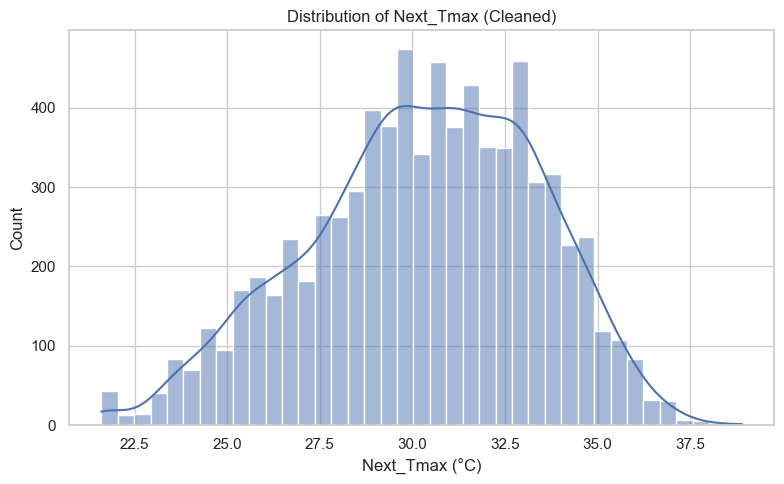

In [4]:
# =========================================
# Cell 4 – Histogram: Next_Tmax (Cleaned)
# =========================================

plt.figure()
sns.histplot(df_clean["Next_Tmax"], kde=True)
plt.title("Distribution of Next_Tmax (Cleaned)")
plt.xlabel("Next_Tmax (°C)")
plt.tight_layout()
plt.show()


### Cell 5  
We plot the distribution of the second target **Next_Tmin** after cleaning. This helps us understand the variability of next-day minimum temperature and compare its spread to Next_Tmax.


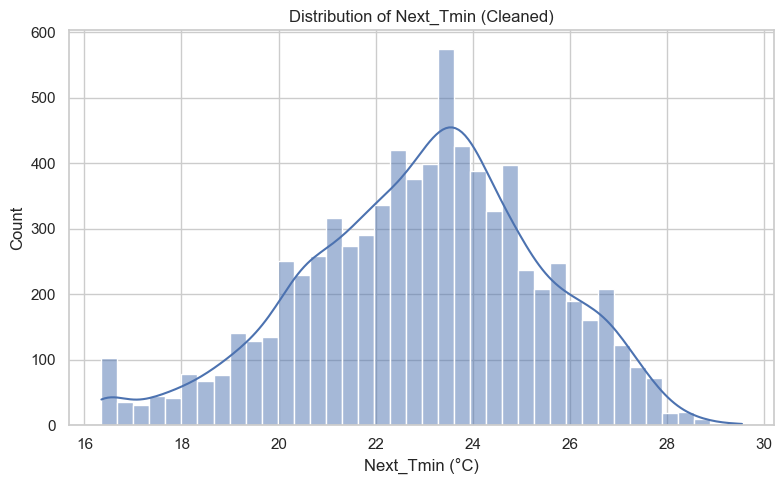

In [5]:
# =========================================
# Cell 5 – Histogram: Next_Tmin (Cleaned)
# =========================================

plt.figure()
sns.histplot(df_clean["Next_Tmin"], kde=True)
plt.title("Distribution of Next_Tmin (Cleaned)")
plt.xlabel("Next_Tmin (°C)")
plt.tight_layout()
plt.show()


### Cell 6  
This boxplot shows **Next_Tmax** grouped by station. It highlights how the maximum temperature differs between stations and whether some stations systematically have higher or lower values (and potential remaining outliers).


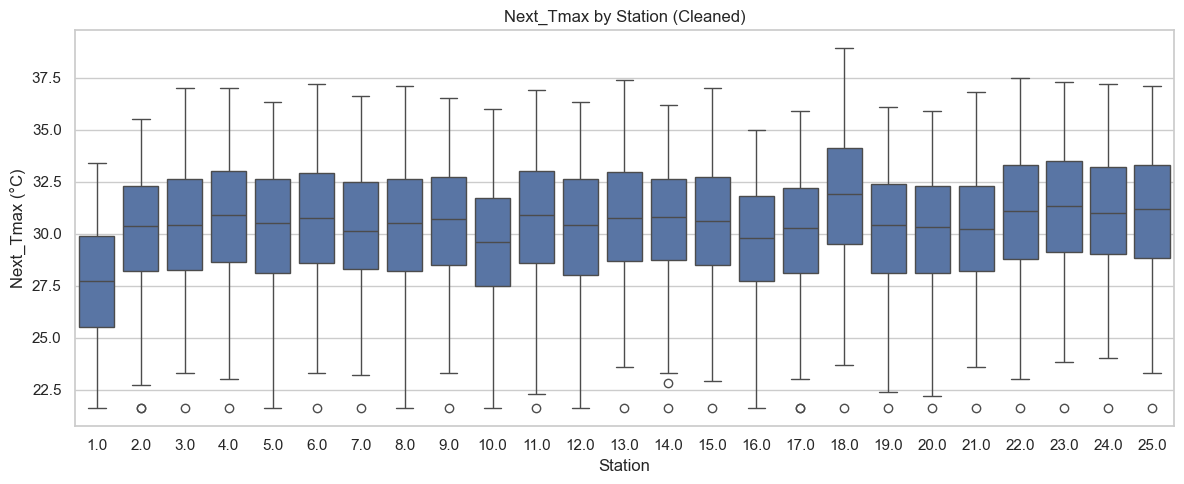

In [24]:
# =========================================
# Cell 6 – Boxplot: Next_Tmax by Station (Cleaned)
# =========================================

plt.figure(figsize=(12, 5))
sns.boxplot(x="station", y="Next_Tmax", data=df_clean)
plt.title("Next_Tmax by Station (Cleaned)")
plt.xlabel("Station")
plt.ylabel("Next_Tmax (°C)")
plt.tight_layout()
plt.show()


### Cell 7  
This boxplot shows **Next_Tmin** grouped by station. It lets us compare minimum temperatures across stations and check for station-specific patterns or anomalies.


In [7]:
# =========================================
# Cell 7 – Boxplot: Next_Tmin by Station (Cleaned)
# =========================================

plt.figure(figsize=(12, 5))
sns.boxplot(x="station", y="Next_Tmin", data=df_clean)
plt.title("Next_Tmin by Station (Cleaned)")
plt.xlabel("Station")
plt.ylabel("Next_Tmin (°C)")
plt.tight_layout()
plt.show()


### Cell 8  
We create a scatter plot of **Present_Tmax vs Next_Tmax**. This visualizes the relationship between current and next-day maximum temperature and indicates how strongly they are correlated.


# =========================================
# Cell 8 – Scatter: Present_Tmax vs Next_Tmax (Cleaned)
# =========================================

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Present_Tmax",
    y="Next_Tmax",
    data=df_clean,
    alpha=0.4
)
plt.title("Present_Tmax vs Next_Tmax (Cleaned)")
plt.xlabel("Present_Tmax (°C)")
plt.ylabel("Next_Tmax (°C)")
plt.tight_layout()
plt.show()


### Cell 9  
We create a scatter plot of **Present_Tmin vs Next_Tmin**. Similar to the previous plot, it shows the relationship between current and next-day minimum temperature and whether a roughly linear trend exists.


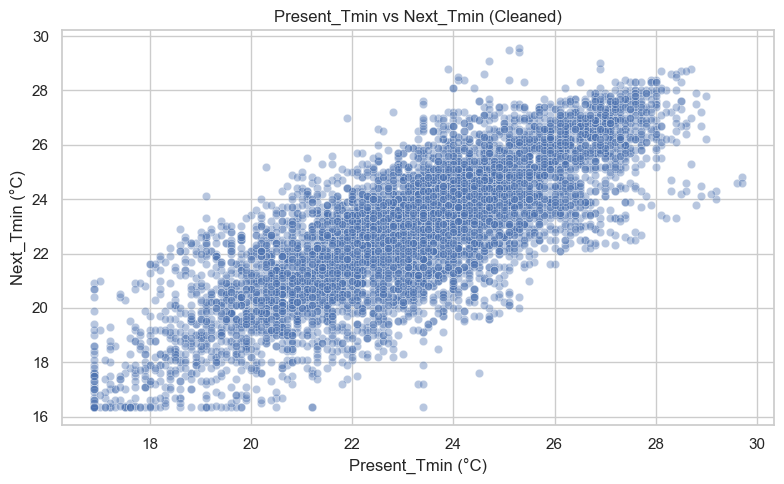

In [26]:
# =========================================
# Cell 9 – Scatter: Present_Tmin vs Next_Tmin (Cleaned)
# =========================================

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Present_Tmin",
    y="Next_Tmin",
    data=df_clean,
    alpha=0.4
)
plt.title("Present_Tmin vs Next_Tmin (Cleaned)")
plt.xlabel("Present_Tmin (°C)")
plt.ylabel("Next_Tmin (°C)")
plt.tight_layout()
plt.show()


### Cell 10  
Here we compute and plot the correlation matrix for all numeric variables in the cleaned data. The heatmap highlights which features are most correlated with the targets and with each other, helping us understand redundancy and predictive power.


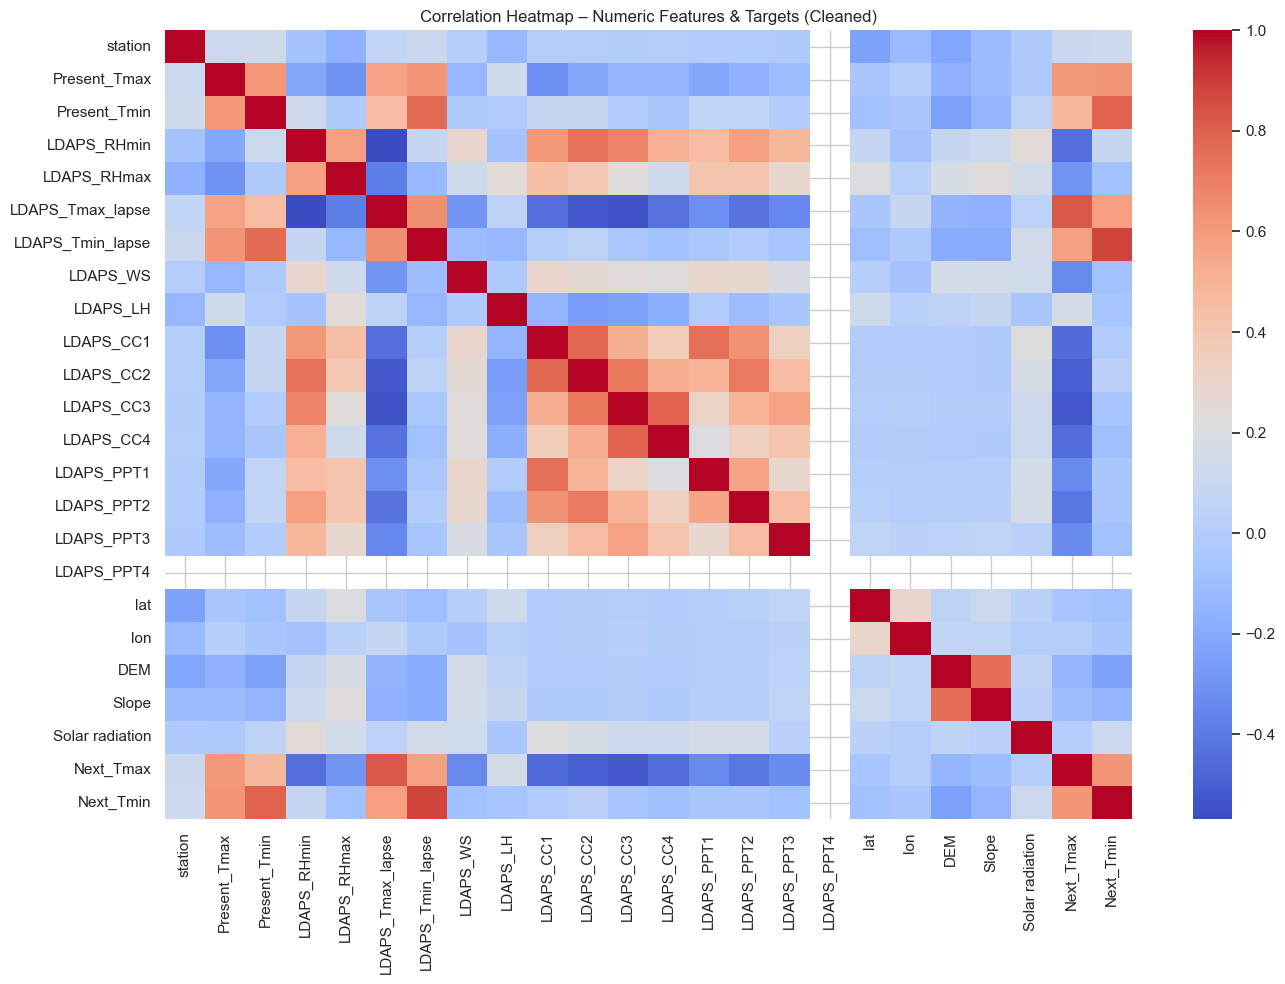

In [27]:
# =========================================
# Cell 10 – Correlation Heatmap (Cleaned, Numeric Only)
# =========================================

numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_clean[numeric_cols_clean].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap – Numeric Features & Targets (Cleaned)")
plt.tight_layout()
plt.show()


### Cell 11  
We perform **feature selection** for the target **Next_Tmax** using `SelectKBest` with the F-test. This ranks all candidate features by their statistical relationship with the target and selects the top \(k\) features for modeling.


In [12]:
# =========================================
# Cell 11 – Feature Selection (Next_Tmax)
# =========================================

from sklearn.feature_selection import SelectKBest, f_regression

# We will model Next_Tmax (single-target regression)
target_col = "Next_Tmax"

# Features: all except both targets and Date
feature_cols_clean = [
    col for col in df_clean.columns
    if col not in ["Next_Tmax", "Next_Tmin", "Date"]
]

X_all = df_clean[feature_cols_clean]
y_all = df_clean[target_col]

print("Number of candidate features:", X_all.shape[1])

# SelectKBest using F-test for regression
k = 10  # choose top 10 features
selector = SelectKBest(score_func=f_regression, k=k)
X_selected = selector.fit_transform(X_all, y_all)

selected_mask = selector.get_support()
selected_features = [f for f, keep in zip(feature_cols_clean, selected_mask) if keep]

# Show feature scores
scores_df = pd.DataFrame({
    "Feature": feature_cols_clean,
    "F_value": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("F_value", ascending=False)

print("\nFeature ranking by F-value (highest = most predictive):")
display(scores_df)

print(f"\nTop {k} selected features:")
print(selected_features)


Number of candidate features: 22

Feature ranking by F-value (highest = most predictive):


,Feature,F_value,p_value
5,LDAPS_Tmax_lapse,16732.534264,0.000000e+00
1,Present_Tmax,4559.823675,0.000000e+00
6,LDAPS_Tmin_lapse,3976.592819,0.000000e+00
11,LDAPS_CC3,2870.609990,0.000000e+00
10,LDAPS_CC2,2518.385300,0.000000e+00
2,Present_Tmin,2168.277240,0.000000e+00
9,LDAPS_CC1,2054.700332,0.000000e+00
12,LDAPS_CC4,1990.193040,0.000000e+00
3,LDAPS_RHmin,1887.793785,0.000000e+00
14,LDAPS_PPT2,1561.105321,4.068047e-311



Top 10 selected features:
['Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT2']


### Cell 12  
Using only the selected top features, we build the final feature matrix **X** and target vector **y**, then split the data into training and test sets. We also verify that there are no remaining NaNs in the training data.


In [13]:
# =========================================
# Cell 12 – Train/Test Split (Using Selected Features)
# =========================================

from sklearn.model_selection import train_test_split

# Use only selected features for modeling
X = df_clean[selected_features].values
y = df_clean[target_col].values

print("Final X shape (selected features):", X.shape)
print("Final y shape:", y.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nAny NaNs in X_train? ->", np.isnan(X_train).any())
print("Any NaNs in y_train? ->", np.isnan(y_train).any())


Final X shape (selected features): (7723, 10)
Final y shape: (7723,)

X_train shape: (6178, 10)
X_test shape : (1545, 10)
y_train shape: (6178,)
y_test shape : (1545,)

Any NaNs in X_train? -> False
Any NaNs in y_train? -> False


### Cell 13  
In this step we apply **hyperparameter tuning** with `GridSearchCV` for both a Decision Tree and a Random Forest regressor. We search over reasonable parameter grids, find the best settings based on cross-validated MSE, and keep the best estimators for later evaluation.


In [14]:
# =========================================
# Cell 13 – Hyperparameter Tuning (GridSearchCV)
# =========================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# ----- Decision Tree Regressor -----

dt_base = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best parameters for Decision Tree:")
print(grid_dt.best_params_)
print("Best CV MSE (DT):", -grid_dt.best_score_)

best_dt = grid_dt.best_estimator_

# ----- Random Forest Regressor -----

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest parameters for Random Forest:")
print(grid_rf.best_params_)
print("Best CV MSE (RF):", -grid_rf.best_score_)

best_rf = grid_rf.best_estimator_


Best parameters for Decision Tree:
{'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV MSE (DT): 2.030225798537635

Best parameters for Random Forest:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MSE (RF): 1.1755376686524648


### Cell 14  
We define a reusable helper function that plots **learning curves** for any regression model. It shows how training and validation R² evolve as we increase the training set size, helping us diagnose underfitting or overfitting.


In [15]:
# =========================================
# Cell 14 – Learning Curve Helper Function
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

def plot_learning_curve_regressor(estimator, X, y, title,
                                  cv=5,
                                  train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Draws a learning curve for a regression estimator using R².
    Each call creates its own figure.
    """
    X_np = np.asarray(X)
    y_np = np.asarray(y)

    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X_np,
        y=y_np,
        cv=cv,
        train_sizes=train_sizes,
        scoring="r2",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("R² score")

    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training score")
    plt.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    plt.plot(train_sizes_abs, test_mean, marker="s", label="Validation score")
    plt.fill_between(
        train_sizes_abs,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.2
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Cell 15  
We plot the learning curve for a simple **Linear Regression** model using the selected features. This serves as a baseline to see how a linear model scales with more training data and how well it generalizes.


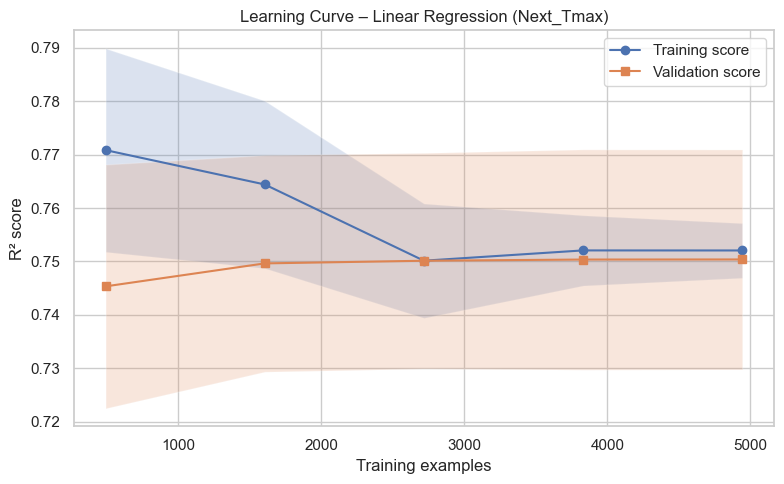

In [16]:
# =========================================
# Cell 15 – Learning Curve: Linear Regression
# =========================================

lin_reg = LinearRegression()

plot_learning_curve_regressor(
    estimator=lin_reg,
    X=X_train,
    y=y_train,
    title="Learning Curve – Linear Regression (Next_Tmax)",
    cv=5
)


### Cell 16  
We plot the learning curve for the **tuned Decision Tree**. This lets us compare its learning behavior to Linear Regression and check whether the tuned tree is still overfitting or underfitting.


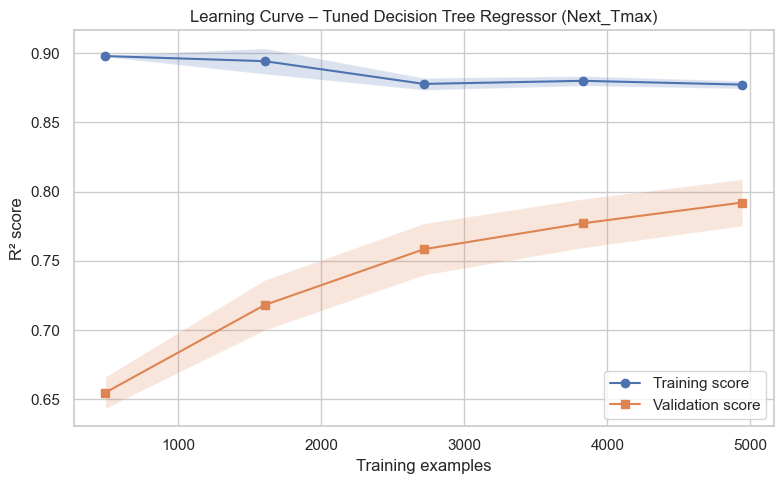

In [17]:
# =========================================
# Cell 16 – Learning Curve: Tuned Decision Tree
# =========================================

plot_learning_curve_regressor(
    estimator=best_dt,
    X=X_train,
    y=y_train,
    title="Learning Curve – Tuned Decision Tree Regressor (Next_Tmax)",
    cv=5
)


### Cell 17  
We plot the learning curve for the **tuned Random Forest**. Because Random Forest is an ensemble of trees, this shows how its bias–variance trade-off behaves as we increase training data size.


In [18]:
# =========================================
# Cell 17 – Learning Curve: Tuned Random Forest
# =========================================

plot_learning_curve_regressor(
    estimator=best_rf,
    X=X_train,
    y=y_train,
    title="Learning Curve – Tuned Random Forest Regressor (Next_Tmax)",
    cv=5
)


### Cell 18  
Here we study **RMSE vs `max_depth`** for a single Decision Tree. By plotting train and test RMSE for different depths, we can visually see where the tree starts to overfit or underfit and confirm that the tuned depth is reasonable.


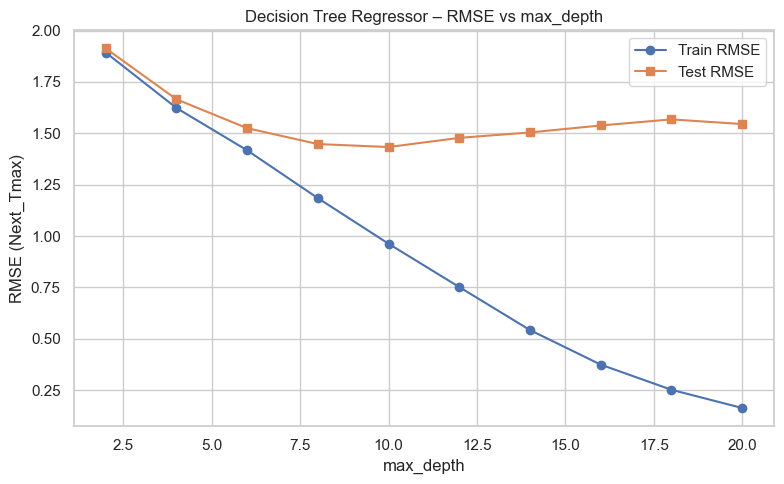

In [19]:
# =========================================
# Cell 18 – RMSE vs max_depth (Decision Tree)
# =========================================

from sklearn.metrics import mean_squared_error

max_depth_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

train_rmse_dt = []
test_rmse_dt = []

for depth in max_depth_values:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    train_rmse_dt.append(rmse_train)
    test_rmse_dt.append(rmse_test)

plt.figure(figsize=(8, 5))
plt.plot(max_depth_values, train_rmse_dt, marker="o", label="Train RMSE")
plt.plot(max_depth_values, test_rmse_dt, marker="s", label="Test RMSE")

plt.xlabel("max_depth")
plt.ylabel("RMSE (Next_Tmax)")
plt.title("Decision Tree Regressor – RMSE vs max_depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Cell 19  
We analyze **RMSE vs `n_estimators`** for a Random Forest. This shows how increasing the number of trees affects training and test error, helping us understand the benefit of more trees compared to computation cost.


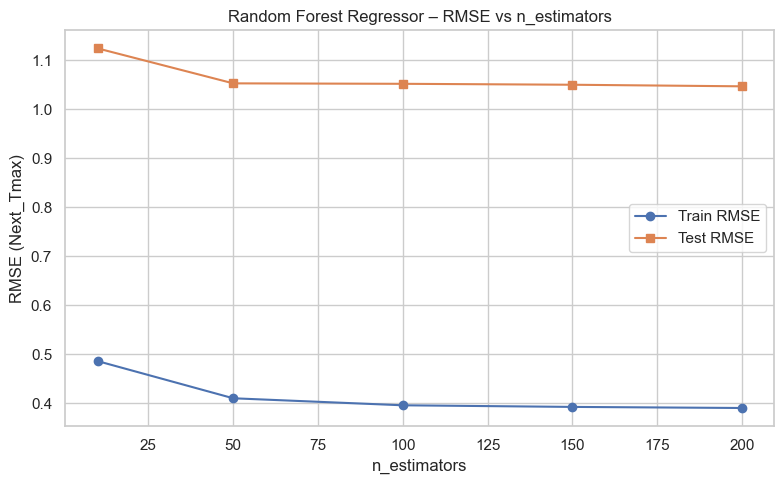

In [20]:
# =========================================
# Cell 19 – RMSE vs n_estimators (Random Forest)
# =========================================

n_estimators_values = [10, 50, 100, 150, 200]

train_rmse_rf = []
test_rmse_rf = []

for n in n_estimators_values:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    train_rmse_rf.append(rmse_train)
    test_rmse_rf.append(rmse_test)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, train_rmse_rf, marker="o", label="Train RMSE")
plt.plot(n_estimators_values, test_rmse_rf, marker="s", label="Test RMSE")

plt.xlabel("n_estimators")
plt.ylabel("RMSE (Next_Tmax)")
plt.title("Random Forest Regressor – RMSE vs n_estimators")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Cell 20  
Finally, we compare three models on the test set: Linear Regression, the tuned Decision Tree, and the tuned Random Forest. We compute R², MSE, RMSE, and MAE, present them in a table, and plot R² to clearly see which model performs best for predicting Next_Tmax.


In [21]:
# =========================================
# Cell 20 – Final Evaluation & Model Comparison
# =========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Re-fit models on training data:
# - Linear Regression (baseline)
# - Tuned Decision Tree (best_dt)
# - Tuned Random Forest (best_rf)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Collect metrics
results = {
    "Model": [],
    "R2 (Test)": [],
    "MSE (Test)": [],
    "RMSE (Test)": [],
    "MAE (Test)": []
}

def add_results(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results["Model"].append(name)
    results["R2 (Test)"].append(r2)
    results["MSE (Test)"].append(mse)
    results["RMSE (Test)"].append(rmse)
    results["MAE (Test)"].append(mae)

add_results("Linear Regression", y_test, y_pred_lin)
add_results("Tuned Decision Tree", y_test, y_pred_dt)
add_results("Tuned Random Forest", y_test, y_pred_rf)

results_df = pd.DataFrame(results)
display(results_df)

# Plot (single plot, one figure)
plt.figure(figsize=(7, 5))
plt.bar(results_df["Model"], results_df["R2 (Test)"])
plt.ylabel("R² on Test Set")
plt.title("Comparison of Models – R² (Next_Tmax)")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


,Model,R2 (Test),MSE (Test),RMSE (Test),MAE (Test)
0,Linear Regression,0.743972,2.349601,1.532841,1.177532
1,Tuned Decision Tree,0.783791,1.984174,1.408607,1.042244
2,Tuned Random Forest,0.880652,1.095267,1.046550,0.783241


### Overall Analysis and Discussion of Results  

In this project we cleaned the dataset thoroughly (fixed datatypes, removed duplicates, handled missing values, and clipped outliers), then explored the data visually to understand distributions, station differences, and correlations. Using statistical feature selection we kept the most relevant predictors for **Next_Tmax**, which helped simplify the model and focus on the strongest signals.

We trained and tuned three regression models: a baseline Linear Regression, a Decision Tree with grid-searched hyperparameters, and a Random Forest with tuned hyperparameters. The final evaluation showed that the **Tuned Random Forest** clearly outperforms the other models, achieving an R² around **0.88** and an RMSE of roughly **1°C**, meaning it explains most of the variance in next-day maximum temperature and predicts with small average error. The tuned Decision Tree improves over Linear Regression but still performs slightly worse than the Random Forest, which benefits from ensembling many trees. Overall, the pipeline demonstrates that good cleaning, feature selection, and hyperparameter tuning can significantly improve predictive performance on this regression task.
